# 02 — SetFit-style (fine-tuning contrastif + LogReg)

**SetFit** (Tunstall et al. 2022) : (1) **fine-tune contrastif** de l'encodeur de
phrases sur des paires même-feuille / feuilles-différentes, puis (2) gel + tête
**LogReg**. Même encodeur, même tête que `01` — la **seule** différence est l'étape
contrastive. Donc `01` vs `02` = *« le fine-tuning contrastif vaut-il son coût en
few-shot ? »*.

> Implémenté via `sentence-transformers` (et non la lib `setfit`, incompatible avec
> transformers 4.41.2) — algorithme identique, plus transparent. Cf. `SOURCES.md`.

On observe aussi l'**espace latent AVANT vs APRÈS** le contrastif (silhouette) :
SetFit resserre-t-il les classes, ou dégrade-t-il la géométrie pré-entraînée ?

In [13]:
import os, sys
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
import helpers as h
DEVICE = h.get_device()
os.makedirs("artifacts", exist_ok=True)

[device] using 'mps' (cuda=False, mps=True) | torch 2.11.0


## Données, taxonomie, splits & embeddings gelés (= 'avant')

In [14]:
df, _ = h.load_m9()
df["_id"] = np.arange(len(df))
tax = h.Taxonomy.from_leaves(df.leaf_label.unique())
splits = h.make_balanced_splits(df, seeds=h.SEEDS)
emb_all = h.cached_st_embeddings(df.text.tolist(), cache_path="artifacts/st_emb_all.npy",
                                 name=h.ENCODER_NAME, device=DEVICE)
print("emb_all:", emb_all.shape, "| seeds:", h.SEEDS)

emb_all: (234, 768) | seeds: [0, 1, 2, 3, 4]


## Entraînement SetFit-style + évaluation — budgets R3 & R8 (5 seeds)

*(le fine-tuning contrastif par seed est la partie lente)*

Deux systèmes partagent exactement le même `run_seed` (train_setfit + setfit_predict) ;
**seul le frame d'entraînement change** :

- **`setfit_8`** (R8) — split complet `n_train=8` (ex-`setfit`, renommé D-05/D-06).
- **`setfit_3`** (R3, ENC-05) — sous-ensemble **niché** `head_per_leaf(tr, 3)` du MÊME split R8
  (PAS un re-split : test set byte-identique, GRID-01/02 ; nichage R3⊂R8 vérifié par seed, GRID-03).

> **Échantillonnage des paires SetFit(3) :** avec 3 ex/feuille, chaque ancre n'a que **2 positifs
> distincts** (l'ancre est exclue depuis PIPE-03 v2.1). `_sample_pairs` tire les positifs avec
> `rng.choice` sur ce pool de 2 — donc **avec remise** — ce qui est le design accepté pour R3 ;
> aucune modification de `_sample_pairs` n'est requise.

_Projection des probabilités par feuille vers des marginales de nœuds cohérentes avec les ancêtres.  
Échantillonnage des paires contrastives SetFit (positives même feuille / négatives autre feuille), déterministe.  
Entraînement SetFit (Tunstall et al. 2022) : fine-tune contrastif de l'encodeur puis tête LogReg.  
Prédiction SetFit : embeddings de l'encodeur fine-tuné + `predict_proba` de la tête LogReg._

In [ ]:
def _sample_pairs(train_texts, train_leaves, pairs_per_example, rng):
    """Build SetFit contrastive pairs as plain ``(text_a, text_b, label)`` tuples.

    Pure helper extracted from ``train_setfit`` so the pair-sampling contract is
    unit-testable without loading mpnet or calling ``st.fit`` (PIPE-03). For each
    anchor it emits ``pairs_per_example`` positives (same leaf) and the same number
    of negatives (other leaf).

    Positive pool excludes the anchor itself — ``pos_pool = [x for x in by_class[l]
    if x != t]`` — so no positive pair is byte-identical (the review's PIPE-03
    intent; previously ~12.5% of positives were trivial ``(t, t)`` identity pairs).
    A degenerate leaf whose texts are all identical empties ``pos_pool`` after the
    exclusion; in that case it falls back to the full pool rather than crashing on
    ``rng.choice([])`` (threat T-06-05). Sampling is deterministic given ``rng``.
    """
    from collections import defaultdict

    by_class: dict[str, list[str]] = defaultdict(list)
    for t, l in zip(train_texts, train_leaves):
        by_class[l].append(t)
    classes = sorted(by_class)

    pairs = []
    for t, l in zip(train_texts, train_leaves):
        others = [c for c in classes if c != l]
        pos_pool = [x for x in by_class[l] if x != t]   # exclude anchor + byte-identical dups
        if not pos_pool:                                # degenerate all-duplicate leaf safeguard
            pos_pool = by_class[l]                      # fall back rather than rng.choice([]) crash
        for _ in range(pairs_per_example):
            pairs.append((t, rng.choice(pos_pool), 1.0))
            nl = rng.choice(others)
            pairs.append((t, rng.choice(by_class[nl]), 0.0))
    return pairs

def train_setfit(train_texts, train_leaves, *, encoder_name: str = h.ENCODER_NAME,
                 seed: int = 0, device: str = "cpu", epochs: int = 1, batch_size: int = 16,
                 pairs_per_example: int = 8):
    """SetFit-STYLE training (Tunstall et al. 2022), implemented via sentence-transformers.

    Two steps, exactly like SetFit: (1) **contrastive fine-tune** the
    sentence-transformer on same-leaf (positive) / different-leaf (negative) pairs
    with a cosine-similarity objective; (2) freeze, encode, fit a **LogReg head**.

    We use ``SentenceTransformer.fit`` directly rather than the ``setfit`` library:
    setfit 1.0.3's Trainer is incompatible with transformers 4.41.2 (the
    ``evaluation_strategy`` -> ``eval_strategy`` rename breaks its callback). The
    algorithm is identical and more transparent for the report.

    Returns ``(st, clf, classes)``: the fine-tuned encoder, the LogReg head, and
    ``clf.classes_`` (sorted leaf strings) for mapping ``predict_proba`` columns.
    """
    import random

    from sentence_transformers import InputExample, SentenceTransformer, losses
    from sklearn.linear_model import LogisticRegression
    from torch.utils.data import DataLoader

    h.set_seed(seed)  # NB: does NOT govern st.fit — the transformers Trainer
    # re-seeds to 42 internally (see RNG-ownership note in the docstring, WR-04).
    st = SentenceTransformer(encoder_name, device=device)
    st.max_seq_length = h.MAX_LENGTH 

    rng = random.Random(seed)

    # Step 1 pairs: per example, sample positives (same leaf) + negatives (other leaf).
    # Delegated to the pure, unit-testable _sample_pairs helper (PIPE-03): the anchor
    # is excluded from its own positive pool so no positive pair is byte-identical.
    examples = [
        InputExample(texts=[a, b], label=lab)
        for (a, b, lab) in _sample_pairs(train_texts, train_leaves, pairs_per_example, rng)
    ]
    loader = DataLoader(examples, shuffle=True, batch_size=batch_size)
    loss = losses.CosineSimilarityLoss(st)
    st.fit(train_objectives=[(loader, loss)], epochs=epochs,
           warmup_steps=max(1, len(loader) // 10), show_progress_bar=True)

    # Step 2: LogReg head on the fine-tuned (then-frozen) embeddings.
    emb = st.encode(list(train_texts), normalize_embeddings=True, convert_to_numpy=True,
                    show_progress_bar=False)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced",
                             random_state=seed).fit(emb, list(train_leaves))
    return st, clf, list(clf.classes_)

def setfit_predict(st, clf, texts, classes=None):
    """Return ``(pred_leaves, leaf_probs, classes)`` from a fitted SetFit-style model."""
    emb = st.encode(list(texts), normalize_embeddings=True, convert_to_numpy=True,
                    show_progress_bar=False)
    proba = clf.predict_proba(emb)              # columns aligned to clf.classes_
    pred = list(clf.predict(emb))
    return pred, proba, list(clf.classes_)


In [ ]:
def run_seed8(seed):
    """R8 SetFit: full n_train=8 train split (renamed from the original `setfit`)."""
    tr, te = splits[seed]["train"], splits[seed]["test"]
    st, clf, classes = train_setfit(tr.text.tolist(), tr.leaf_label.tolist(),
                                      encoder_name=h.ENCODER_NAME, seed=seed,
                                      device=DEVICE, epochs=1, batch_size=16)
    pred, prob, classes = setfit_predict(st, clf, te.text.tolist())
    marg = h.flat_leaf_probs_to_marginals(prob, classes, tax)
    return st, pred, marg, h.all_metrics(pred, marg, te.leaf_label.tolist(), tax), te, prob


def run_seed3(seed):
    """R3 SetFit : nested head(3) train of the SAME R8 split. train_setfit is
    reused UNCHANGED — only the train frame shrinks. No re-split, so the test
    set is byte-identical to R8. With 3 ex/leaf each anchor has only 2 distinct
    positives; `_sample_pairs` samples those WITH REPLACEMENT 
    """
    tr, te = splits[seed]["train"], splits[seed]["test"]
    tr3 = h.head_per_leaf(tr, 3)                       
    assert set(tr3._id) <= set(tr._id), "R3 train not a subset of R8 train (GRID-03)"
    st, clf, classes = train_setfit(tr3.text.tolist(), tr3.leaf_label.tolist(),
                                      encoder_name=h.ENCODER_NAME, seed=seed,
                                      device=DEVICE, epochs=1, batch_size=16)
    pred, prob, classes = setfit_predict(st, clf, te.text.tolist())
    marg = h.flat_leaf_probs_to_marginals(prob, classes, tax)
    return st, pred, marg, h.all_metrics(pred, marg, te.leaf_label.tolist(), tax), te, prob


def emit_system(MODEL, run_fn):
    """Per-system seed loop + full artifact family (D-07): long-format metrics CSV +
    provenance .meta.json + probs/correct npz (str(seed) keys) + seed-0 diagnostics.
    Keeps the seed-0 fine-tuned body `st` for the latent-space (silhouette) cell."""
    import json
    rows, keep0 = [], {}
    probs_by_seed, correct_by_seed = {}, {}
    for seed in h.SEEDS:
        st, pred, marg, metrics, te, prob = run_fn(seed)
        for k, v in metrics.items():
            rows.append({"model": MODEL, "seed": seed, "metric": k, "value": v})
        probs_by_seed[str(seed)] = prob
        correct_by_seed[str(seed)] = np.asarray(pred) == te.leaf_label.values
        if seed == 0:
            keep0 = {"st": st, "pred": pred, "marg": marg, "te": te}
        print(f"[{MODEL}] seed {seed}: " + "  ".join(f"{k}={v:.3f}" for k, v in metrics.items()))
    res = pd.DataFrame(rows)
    res.to_csv(f"artifacts/metrics_{MODEL}.csv", index=False)
    with open(f"artifacts/metrics_{MODEL}.csv.meta.json", "w") as fh:
        json.dump(h.provenance(), fh)            # PIPE-05 provenance sidecar
    np.savez(f"artifacts/probs_{MODEL}.npz", **probs_by_seed)
    np.savez(f"artifacts/correct_{MODEL}.npz", **correct_by_seed)
    print(f"-> artifacts/metrics_{MODEL}.csv (+ .meta.json, probs/correct npz)")
    return res, keep0


def agg_metrics(res):
    return (res.groupby("metric").value.agg(["mean", "std"])
               .reindex(["leaf_accuracy", "leaf_macro_f1", "h_micro_f1",
                         "h_samples_f1", "h_macro_f1", "hf1_auc"]))


def diagnostics(MODEL, keep0):
    """D-08 diagnostics trio for one system: confusion matrix (seed 0),
    top-10 confused pairs, and the errors_{MODEL}_seed0.csv export."""
    pred0, te0 = keep0["pred"], keep0["te"]
    labels = sorted(tax.terminals)
    fig, ax = plt.subplots(figsize=(10, 8))
    h.plot_confusion(te0.leaf_label.tolist(), pred0, labels=labels, ax=ax,
                     title=f"{MODEL} — confusion (seed 0)")
    plt.tight_layout(); plt.show()
    print(f"[{MODEL}] paires les plus confondues (seed 0):")
    display(h.top_confused_pairs(te0.leaf_label.tolist(), pred0, k=10))
    err = te0.assign(pred=pred0)
    err = err[err.leaf_label != err.pred]
    print(f"[{MODEL}] {len(err)}/{len(te0)} erreurs (seed 0)")
    err[["_id", "leaf_label", "pred", "text"]].to_csv(
        f"artifacts/errors_{MODEL}_seed0.csv", index=False)
    print(f"-> artifacts/errors_{MODEL}_seed0.csv")
    return err


In [ ]:
# Emit both budgets. setfit_8 keep0 carries the seed-0 fine-tuned body `st` for the
# latent-space (silhouette) cell below. setfit_3 reuses the SAME emit/run path.
res8, keep0 = emit_system("setfit_8", run_seed8)     # R8 (renamed from "setfit", D-05/D-06)
res3, keep0_3 = emit_system("setfit_3", run_seed3)   # R3 nested head(3) train (ENC-05)


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
  0%|          | 0/104 [00:00<?, ?it/s]/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 104/104 [00:57<00:00,  1.81it/s]


{'train_runtime': 57.4385, 'train_samples_per_second': 28.97, 'train_steps_per_second': 1.811, 'train_loss': 0.0815886350778433, 'epoch': 1.0}
[setfit_8] seed 0: leaf_accuracy=0.762  leaf_macro_f1=0.762  h_micro_p=0.862  h_micro_r=0.844  h_micro_f1=0.853  h_samples_f1=0.853  h_macro_f1=0.808  hf1_auc=0.867


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
  0%|          | 0/104 [00:00<?, ?it/s]/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 104/104 [01:00<00:00,  1.71it/s]


{'train_runtime': 60.7872, 'train_samples_per_second': 27.374, 'train_steps_per_second': 1.711, 'train_loss': 0.08352870207566482, 'epoch': 1.0}
[setfit_8] seed 1: leaf_accuracy=0.815  leaf_macro_f1=0.817  h_micro_p=0.859  h_micro_r=0.859  h_micro_f1=0.859  h_samples_f1=0.866  h_macro_f1=0.840  hf1_auc=0.890


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
  0%|          | 0/104 [00:00<?, ?it/s]/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 104/104 [01:59<00:00,  1.15s/it]


...

{'train_runtime': 68.0177, 'train_samples_per_second': 9.174, 'train_steps_per_second': 0.573, 'train_loss': 0.10326068829267453, 'epoch': 1.0}
[setfit_3] seed 2: leaf_accuracy=0.723  leaf_macro_f1=0.712  h_micro_p=0.850  h_micro_r=0.847  h_micro_f1=0.848  h_samples_f1=0.853  h_macro_f1=0.782  hf1_auc=0.659


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
  0%|          | 0/39 [00:00<?, ?it/s]/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 39/39 [01:06<00:00,  1.70s/it]


{'train_runtime': 66.152, 'train_samples_per_second': 9.433, 'train_steps_per_second': 0.59, 'train_loss': 0.09761219146924141, 'epoch': 1.0}
[setfit_3] seed 3: leaf_accuracy=0.654  leaf_macro_f1=0.642  h_micro_p=0.777  h_micro_r=0.771  h_micro_f1=0.774  h_samples_f1=0.781  h_macro_f1=0.704  hf1_auc=0.645


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
  0%|          | 0/39 [00:00<?, ?it/s]/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 39/39 [01:02<00:00,  1.60s/it]


{'train_runtime': 62.3725, 'train_samples_per_second': 10.004, 'train_steps_per_second': 0.625, 'train_loss': 0.08164093433282314, 'epoch': 1.0}
[setfit_3] seed 4: leaf_accuracy=0.654  leaf_macro_f1=0.639  h_micro_p=0.799  h_micro_r=0.771  h_micro_f1=0.784  h_samples_f1=0.785  h_macro_f1=0.704  hf1_auc=0.682
-> artifacts/metrics_setfit_3.csv (+ .meta.json, probs/correct npz)


## Métriques agrégées (mean ± std, 5 seeds) — R8 puis R3

In [18]:
print("setfit_8 (R8):")
display(agg_metrics(res8).style.format("{:.3f}"))
print("setfit_3 (R3):")
display(agg_metrics(res3).style.format("{:.3f}"))


setfit_8 (R8):


,mean,std
metric,,
leaf_accuracy,0.795,0.036
leaf_macro_f1,0.795,0.036
h_micro_f1,0.865,0.016
h_samples_f1,0.868,0.019
h_macro_f1,0.831,0.026
hf1_auc,0.879,0.018


setfit_3 (R3):


,mean,std
metric,,
leaf_accuracy,0.685,0.046
leaf_macro_f1,0.677,0.048
h_micro_f1,0.801,0.039
h_samples_f1,0.804,0.040
h_macro_f1,0.738,0.045
hf1_auc,0.663,0.020


## Analyse des erreurs (seed 0) — R8 & R3 (diagnostics D-08)

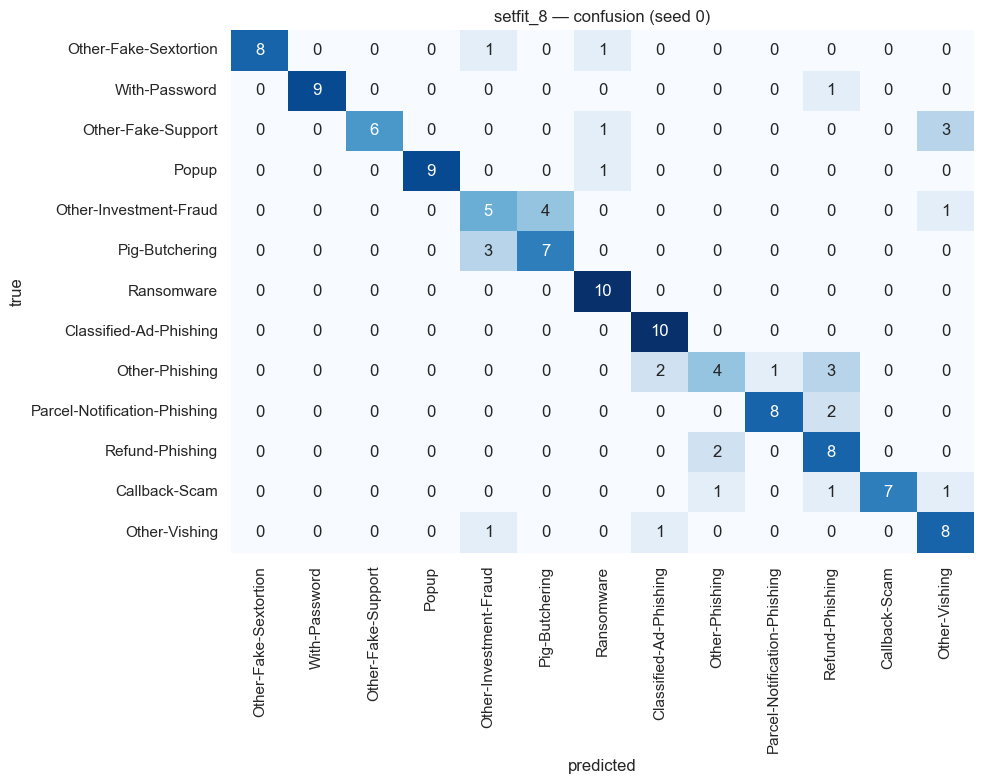

[setfit_8] paires les plus confondues (seed 0):


,true,pred,count
0,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Investment-Fraud/Pig-Butchering,4
1,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Other-Vishing,3
2,Fraud/Investment-Fraud/Pig-Butchering,Fraud/Investment-Fraud/Other-Investment-Fraud,3
3,Phishing/Other-Phishing,Phishing/Refund-Phishing,3
4,Phishing/Other-Phishing,Phishing/Classified-Ad-Phishing,2
5,Phishing/Parcel-Notification-Phishing,Phishing/Refund-Phishing,2
6,Phishing/Refund-Phishing,Phishing/Other-Phishing,2
7,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Investment-Fraud/Other-Investment-Fraud,1
8,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Malware/Ransomware,1
9,Fraud/Fake-Sextortion/With-Password,Phishing/Refund-Phishing,1


[setfit_8] 31/130 erreurs (seed 0)
-> artifacts/errors_setfit_8_seed0.csv


In [19]:
_ = diagnostics("setfit_8", keep0)

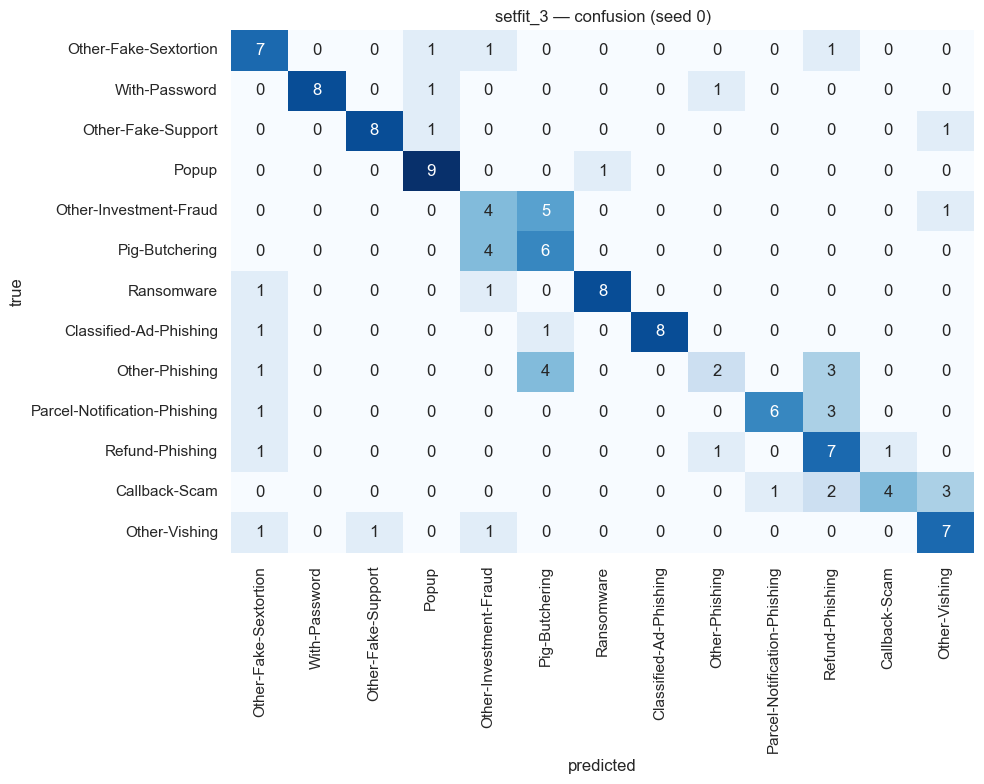

[setfit_3] paires les plus confondues (seed 0):


,true,pred,count
0,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Investment-Fraud/Pig-Butchering,5
1,Fraud/Investment-Fraud/Pig-Butchering,Fraud/Investment-Fraud/Other-Investment-Fraud,4
2,Phishing/Other-Phishing,Fraud/Investment-Fraud/Pig-Butchering,4
3,Phishing/Other-Phishing,Phishing/Refund-Phishing,3
4,Phishing/Parcel-Notification-Phishing,Phishing/Refund-Phishing,3
5,Phishing/Vishing/Callback-Scam,Phishing/Vishing/Other-Vishing,3
6,Phishing/Vishing/Callback-Scam,Phishing/Refund-Phishing,2
7,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Investment-Fraud/Other-Investment-Fraud,1
8,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Fake-Support/Popup,1
9,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Phishing/Refund-Phishing,1


[setfit_3] 46/130 erreurs (seed 0)
-> artifacts/errors_setfit_3_seed0.csv


In [20]:
_ = diagnostics("setfit_3", keep0_3)

In [21]:
# Aperçu des erreurs setfit_8 (seed 0) — le CSV est déjà exporté par diagnostics() ci-dessus.
te0 = keep0["te"]
err = te0.assign(pred=keep0["pred"])
err = err[err.leaf_label != err.pred]
display(err[["leaf_label", "pred", "text"]]
        .assign(text=lambda d: d.text.str.slice(0, 90)).head(15))


,leaf_label,pred,text
0,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Fraud/Investment-Fraud/Other-Investment-Fraud,"The only ""ID"" of the scammer I have is their B..."
1,Fraud/Fake-Sextortion/Other-Fake-Sextortion,Malware/Ransomware,somebody claims that he installed Pegasus spy ...
16,Fraud/Fake-Sextortion/With-Password,Phishing/Refund-Phishing,Subject: A b 0ut your p@ ssw0rd\n\nH ell o.\n\...
22,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Other-Vishing,My elderly mother received a phone call from s...
24,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Other-Vishing,I received a phone call at 19.31 on Thursday 1...
25,Fraud/Fake-Support/Other-Fake-Support,Malware/Ransomware,"A security check from ""Microsoft"" wanted me to..."
29,Fraud/Fake-Support/Other-Fake-Support,Phishing/Vishing/Other-Vishing,I received a call today from +44.1268.709.559 ...
35,Fraud/Fake-Support/Popup,Malware/Ransomware,I received an alarm on my laptop to say a secu...
42,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Investment-Fraud/Pig-Butchering,https://bytesi.vip\n\nMy friend contacted me t...
43,Fraud/Investment-Fraud/Other-Investment-Fraud,Fraud/Investment-Fraud/Pig-Butchering,"Hello \n\nI am reporting criminal acts,and ha..."


## Espace latent — AVANT vs APRÈS le fine-tuning contrastif (setfit_8, seed 0)

À gauche : embeddings **gelés** (avant SetFit = ce que voit le linear probe `01`).
À droite : embeddings du **corps fine-tuné** (après le contrastif, R8). Le **silhouette**
(cosinus), mesuré **sur le test (seed 0)**

_Embeddings de l'encodeur fine-tuné — la géométrie « après SetFit ».  
Score de silhouette cosinus — plus élevé = clusters par étiquette plus nets (avant/après SetFit)._

In [22]:
def setfit_body_embed(st, texts, normalize: bool = True) -> np.ndarray:
    """Embeddings from the fine-tuned encoder — the "after SetFit" geometry."""
    return st.encode(list(texts), normalize_embeddings=normalize,
                     convert_to_numpy=True, show_progress_bar=False)

def silhouette(emb, labels) -> float:
    """Cosine silhouette score — higher = tighter/cleaner per-label clusters.

    A single number to back the before/after-SetFit latent-space plots: does the
    contrastive step actually separate the classes better, or degrade the geometry?
    """
    from sklearn.metrics import silhouette_score

    return float(silhouette_score(np.asarray(emb), list(labels), metric="cosine"))


silhouette AVANT (gelé)  : 0.070
silhouette APRÈS (SetFit): 0.241
Δ = +0.171  ->  le contrastif SÉPARE mieux


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


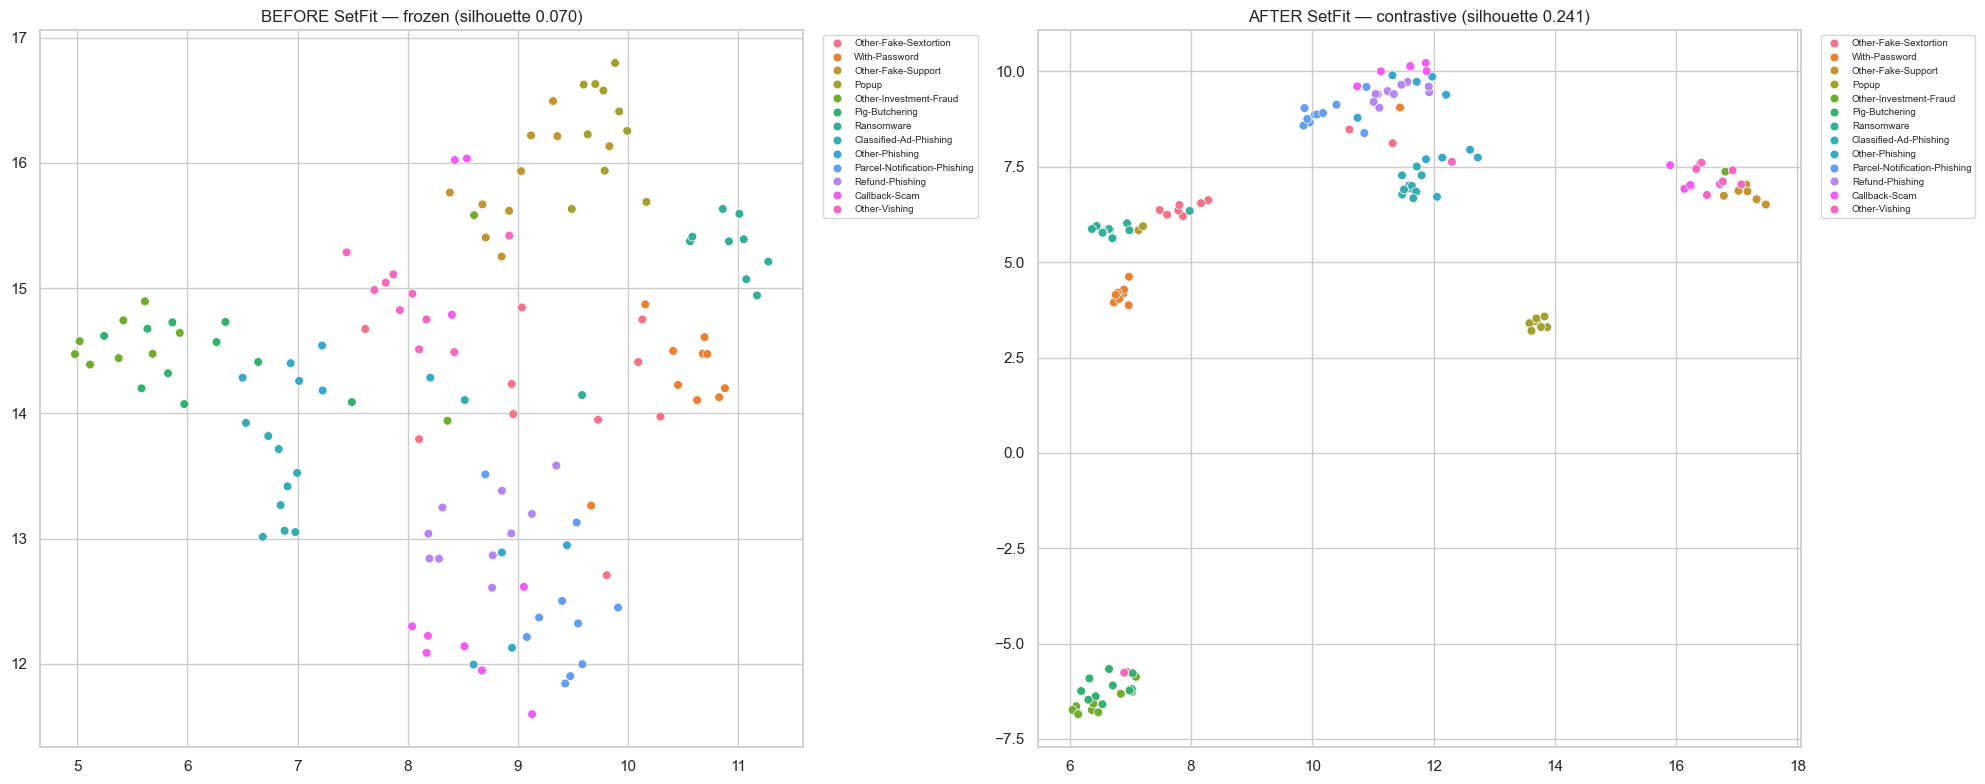

In [26]:
te0 = keep0["te"]
before = emb_all[te0._id.values]
after = setfit_body_embed(keep0["st"], te0.text.tolist())
sil_before = silhouette(before, te0.leaf_label.tolist())
sil_after = silhouette(after, te0.leaf_label.tolist())
print(f"silhouette AVANT (gelé)  : {sil_before:.3f}")
print(f"silhouette APRÈS (SetFit): {sil_after:.3f}")
print(f"Δ = {sil_after - sil_before:+.3f}  ->  "
      + ("le contrastif SÉPARE mieux" if sil_after > sil_before else "le contrastif DÉGRADE la géométrie"))
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
h.plot_latent(before, te0.leaf_label.tolist(), method="umap", ax=ax[0],
              title=f"BEFORE SetFit — frozen (silhouette {sil_before:.3f})")
h.plot_latent(after, te0.leaf_label.tolist(), method="umap", ax=ax[1],
              title=f"AFTER SetFit — contrastive (silhouette {sil_after:.3f})")
plt.tight_layout(); plt.show()

## Le niveau 1 (catégorie principale) — AVANT vs APRÈS SetFit

Même projection que ci-dessus, mais colorée par **niveau 1** (la racine de la
hiérarchie) au lieu de la feuille. On voit ainsi comment le contrastif réorganise
les grandes familles : si les blocs lvl1 se resserrent / se séparent après SetFit,
le fine-tuning structure aussi le niveau principal, pas seulement les feuilles.

silhouette lvl1 AVANT (gelé)  : 0.053
silhouette lvl1 APRÈS (SetFit): 0.141
Δ = +0.088  ->  le contrastif SÉPARE mieux le niveau 1


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


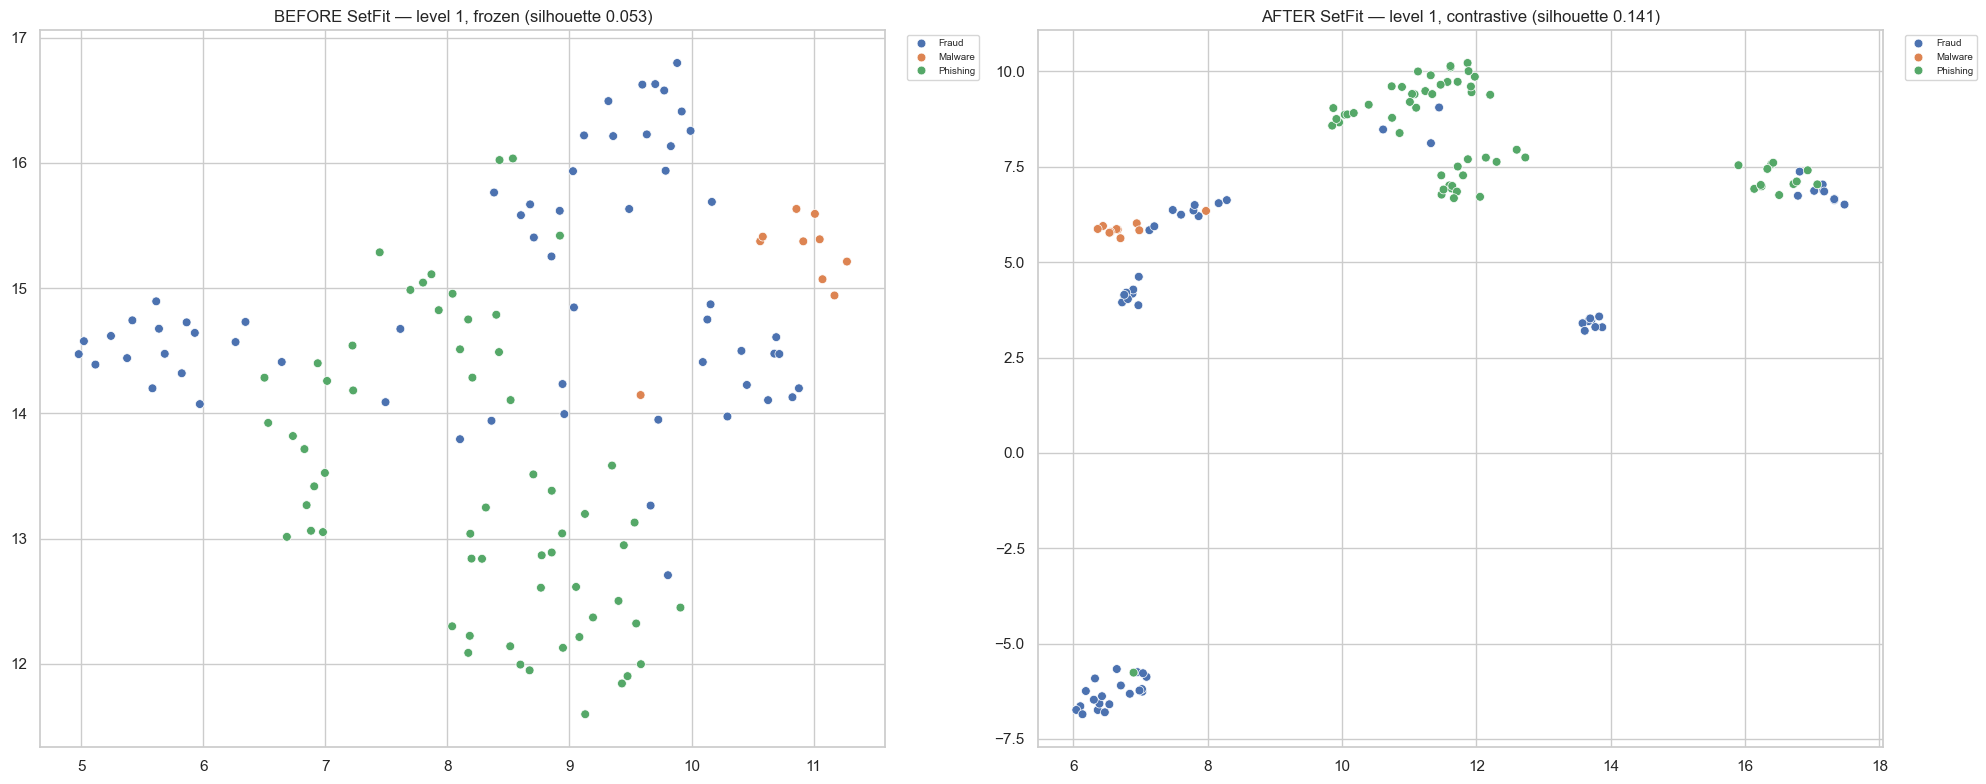

In [27]:
# Même espace latent, mais coloré par niveau 1 (catégorie principale) — réutilise
# `before`/`after`/`te0` calculés ci-dessus (pas de 2e encodage).
sil1_before = silhouette(before, te0.lvl1.tolist())
sil1_after = silhouette(after, te0.lvl1.tolist())
print(f"silhouette lvl1 AVANT (gelé)  : {sil1_before:.3f}")
print(f"silhouette lvl1 APRÈS (SetFit): {sil1_after:.3f}")
print(f"Δ = {sil1_after - sil1_before:+.3f}  ->  "
      + ("le contrastif SÉPARE mieux le niveau 1" if sil1_after > sil1_before
         else "le contrastif DÉGRADE la géométrie du niveau 1"))
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
h.plot_latent(before, te0.lvl1.tolist(), method="umap", ax=ax[0],
              title=f"BEFORE SetFit — level 1, frozen (silhouette {sil1_before:.3f})")
h.plot_latent(after, te0.lvl1.tolist(), method="umap", ax=ax[1],
              title=f"AFTER SetFit — level 1, contrastive (silhouette {sil1_after:.3f})")
plt.tight_layout(); plt.show()

## Le niveau 2 (sous-catégorie) — AVANT vs APRÈS SetFit

Même projection que ci-dessus, mais colorée par **niveau 2** (la sous-catégorie sous
la racine) au lieu de la feuille. On voit ainsi comment le contrastif réorganise
les sous-familles : si les blocs lvl2 se resserrent / se séparent après SetFit,
le fine-tuning structure aussi le niveau intermédiaire, pas seulement les feuilles.

silhouette lvl2 AVANT (gelé)  : 0.087
silhouette lvl2 APRÈS (SetFit): 0.235
Δ = +0.148  ->  le contrastif SÉPARE mieux le niveau 2


/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


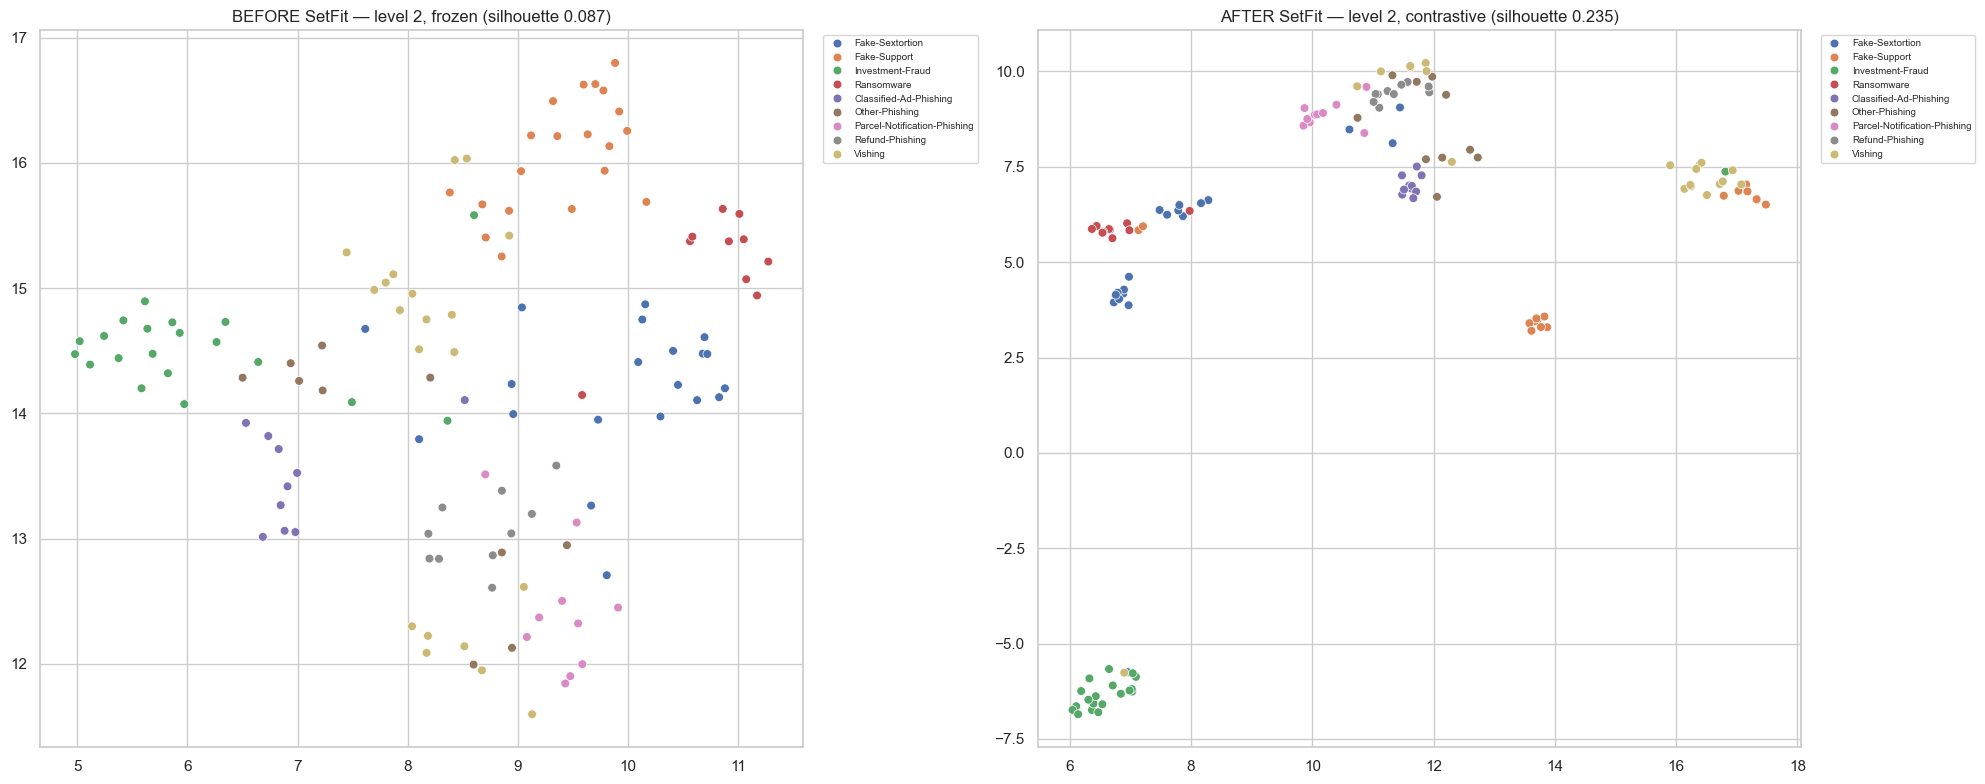

In [28]:
# Même espace latent, mais coloré par niveau 2 (sous-catégorie) — réutilise
# `before`/`after`/`te0` calculés ci-dessus (pas de 2e encodage).
sil2_before = silhouette(before, te0.lvl2.tolist())
sil2_after = silhouette(after, te0.lvl2.tolist())
print(f"silhouette lvl2 AVANT (gelé)  : {sil2_before:.3f}")
print(f"silhouette lvl2 APRÈS (SetFit): {sil2_after:.3f}")
print(f"Δ = {sil2_after - sil2_before:+.3f}  ->  "
      + ("le contrastif SÉPARE mieux le niveau 2" if sil2_after > sil2_before
         else "le contrastif DÉGRADE la géométrie du niveau 2"))
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
h.plot_latent(before, te0.lvl2.tolist(), method="umap", ax=ax[0],
              title=f"BEFORE SetFit — level 2, frozen (silhouette {sil2_before:.3f})")
h.plot_latent(after, te0.lvl2.tolist(), method="umap", ax=ax[1],
              title=f"AFTER SetFit — level 2, contrastive (silhouette {sil2_after:.3f})")
plt.tight_layout(); plt.show()

## Exemples « à la frontière » — points près d'une AUTRE catégorie (seed 0)

Les 5 exemples du test (seed 0) dont le **voisinage UMAP est le plus dominé par une
autre catégorie de niveau 1** — typiquement *un phishing posé au milieu des fraudes*.
Calculé sur l'espace **APRÈS SetFit** (panneau de droite). On affiche le **texte complet**
de chacun et on les **numérote (1–5)** sur la projection pour les retrouver à l'œil.

/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/homer/_mygit/CAS-HTC/.cas-htc/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


5 exemples près d'une autre catégorie (espace APRÈS SetFit, seed 0) :

#1  vrai lvl1 = Phishing  ->  entouré de « Fraud » (100% des 10 voisins d'une autre catégorie)
     feuille : Phishing/Vishing/Other-Vishing
     texte   : They mentioned in a badly generated voice that a fraudulent bitcoin transaction on my Paypal account for around 600 was made, I hang up immediately
----------------------------------------------------------------------------------------------------
#2  vrai lvl1 = Fraud  ->  entouré de « Phishing » (100% des 10 voisins d'une autre catégorie)
     feuille : Fraud/Fake-Sextortion/With-Password
     texte   : Subject: A b 0ut your p@ ssw0rd

H ell o.

I'll s kip the s ma ll t alk. I kn ow your p ass w0rd: Nikita_2011

A few mon ths ag o I in stalled a tr ojan on your dev ice. Sin ce then I've been wat ching ev erything you do.

I have c lips of you wat ching v ery pr ivate co ntent. I have your full co ntact li st. I will sh are them with ev eryone you kn ow if you 

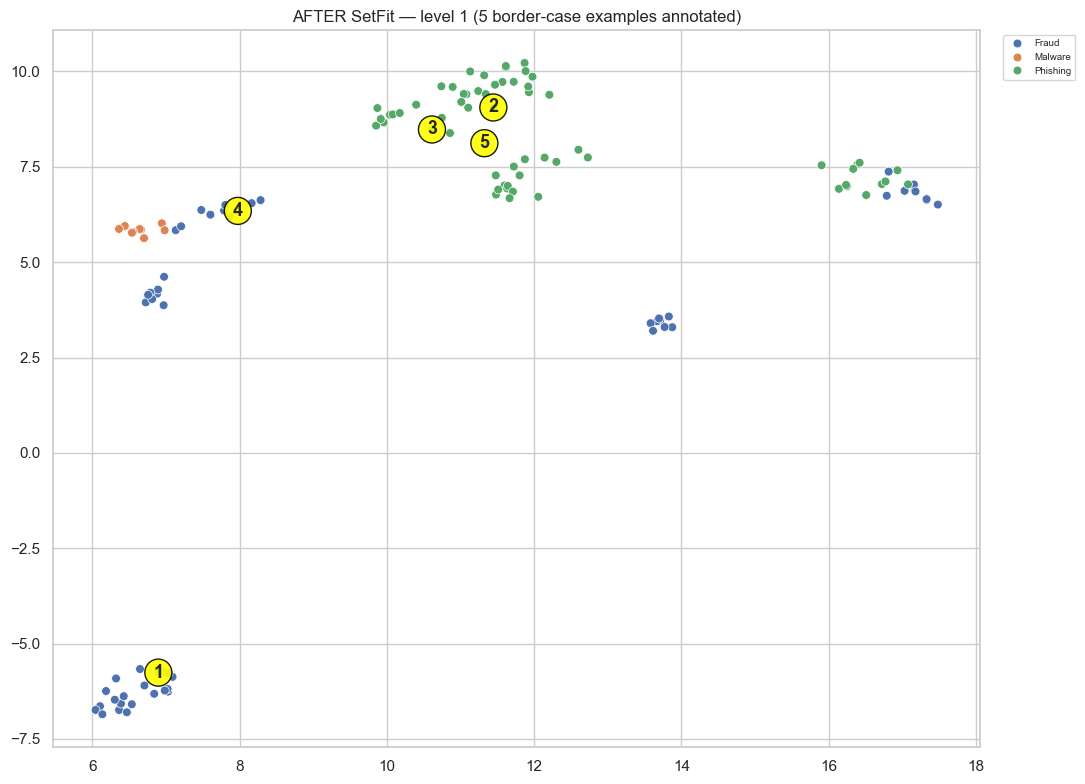

In [29]:
# 5 exemples "frontaliers" : points dont le voisinage UMAP est dominé par une AUTRE
# catégorie de niveau 1 (ex. un phishing au milieu des fraudes). Espace APRÈS SetFit,
# seed 0. h.plot_latent recalcule la MÊME UMAP (random_state=0) -> nos coords == le plot.
from collections import Counter
from sklearn.neighbors import NearestNeighbors
import umap

lvl1 = te0.lvl1.to_numpy()
xy_after = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(after)

K = 10
_, idx = NearestNeighbors(n_neighbors=K + 1).fit(xy_after).kneighbors(xy_after)
idx = idx[:, 1:]                                              # retire le point lui-même
foreign_frac = np.array([(lvl1[nb] != lvl1[i]).mean() for i, nb in enumerate(idx)])

def dominant_foreign(i):
    others = [lvl1[j] for j in idx[i] if lvl1[j] != lvl1[i]]
    return Counter(others).most_common(1)[0][0] if others else None

order = np.argsort(-foreign_frac)[:5]                        # les plus entourés d'étranger

print("5 exemples près d'une autre catégorie (espace APRÈS SetFit, seed 0) :\n")
for rank, i in enumerate(order, 1):
    dom = dominant_foreign(i)
    print(f"#{rank}  vrai lvl1 = {lvl1[i]}  ->  entouré de « {dom} » "
          f"({foreign_frac[i]*100:.0f}% des {K} voisins d'une autre catégorie)")
    print(f"     feuille : {te0.leaf_label.iloc[i]}")
    print(f"     texte   : {te0.text.iloc[i]}")
    print("-" * 100)

# Repère visuel : numérote les 5 points sur la projection APRÈS SetFit (niveau 1).
fig, ax = plt.subplots(figsize=(11, 8))
h.plot_latent(after, lvl1.tolist(), method="umap", ax=ax,
              title="AFTER SetFit — level 1 (5 border-case examples annotated)")
for rank, i in enumerate(order, 1):
    ax.annotate(str(rank), (xy_after[i, 0], xy_after[i, 1]),
                fontsize=13, fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="circle,pad=0.25", fc="yellow", ec="black", alpha=0.9))
plt.tight_layout(); plt.show()

## Exemples mal classés — setfit_8 (seed 0)

Liste complète des exemples du **seed 0** dont `pred ≠ leaf_label` (issus de `keep0`, le même objet que `diagnostics("setfit_8", keep0)`), même présentation que la cellule « frontaliers ».

In [30]:
# Exemples mal classes par setfit_8 (seed 0) — meme presentation que la cellule frontaliere.
# Source : keep0 (= diagnostics("setfit_8", keep0)) -> pred + test-frame seed 0.
te0 = keep0["te"]
pred0 = np.asarray(keep0["pred"])
miss = np.where(te0.leaf_label.values != pred0)[0]

print(f"setfit_8 — {len(miss)}/{len(te0)} exemples mal classes (seed 0) :\n")
for rank, i in enumerate(miss, 1):
    print(f"#{rank}  vrai = {te0.leaf_label.iloc[i]}  ->  predit << {pred0[i]} >>")
    print(f"     texte   : {te0.text.iloc[i]}")
    print("-" * 100)

setfit_8 — 31/130 exemples mal classes (seed 0) :

#1  vrai = Fraud/Fake-Sextortion/Other-Fake-Sextortion  ->  predit << Fraud/Investment-Fraud/Other-Investment-Fraud >>
     texte   : The only "ID" of the scammer I have is their Bitcoin account (mail claims to come from my own address)
1DwPNjUKiUi9HZNC3xAeKgfYX1D3ks1Gjt

Would it be helpful if I forward the scam mail to an address of yours?
----------------------------------------------------------------------------------------------------
#2  vrai = Fraud/Fake-Sextortion/Other-Fake-Sextortion  ->  predit << Malware/Ransomware >>
     texte   : somebody claims that he installed Pegasus spy ware on my computers and smartphones and recorded some compromising videos which may be available to my all contacts on WhatsApp, Telegram, email etc.. if I do not transfer money to a Litecoin account within 48 hours.
----------------------------------------------------------------------------------------------------
#3  vrai = Fraud/Fake-Sextortion